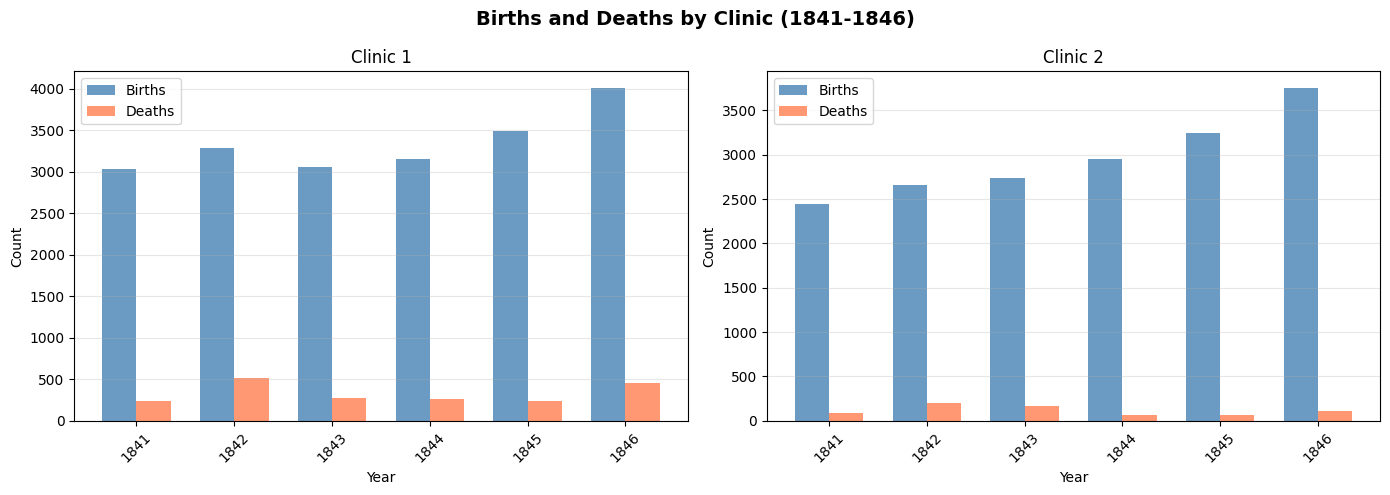

In [6]:
import matplotlib.pyplot as plt
import numpy as np

data = {
    "year": [1841,1842,1843,1844,1845,1846,
             1841,1842,1843,1844,1845,1846],
    "births": [3036,3287,3060,3157,3492,4010,
               2442,2659,2739,2956,3241,3754],
    "deaths": [237,518,274,260,241,459,
               86,202,164,68,66,105],
    "clinic": ["clinic 1"]*6 + ["clinic 2"]*6
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

# Extract data for each clinic
years = data["year"][:6]
clinic1_births = data["births"][:6]
clinic1_deaths = data["deaths"][:6]
clinic2_births = data["births"][6:]
clinic2_deaths = data["deaths"][6:]

# Plot clinic 1
x = np.arange(len(years))
width = 0.35
axes[0].bar(x - width/2, clinic1_births, width, label='Births', color='steelblue', alpha=0.8)
axes[0].bar(x + width/2, clinic1_deaths, width, label='Deaths', color='coral', alpha=0.8)
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Count')
axes[0].set_title('Clinic 1')
axes[0].set_xticks(x)
axes[0].set_xticklabels(years, rotation=45)
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Plot clinic 2
axes[1].bar(x - width/2, clinic2_births, width, label='Births', color='steelblue', alpha=0.8)
axes[1].bar(x + width/2, clinic2_deaths, width, label='Deaths', color='coral', alpha=0.8)
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Count')
axes[1].set_title('Clinic 2')
axes[1].set_xticks(x)
axes[1].set_xticklabels(years, rotation=45)
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Births and Deaths by Clinic (1841-1846)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

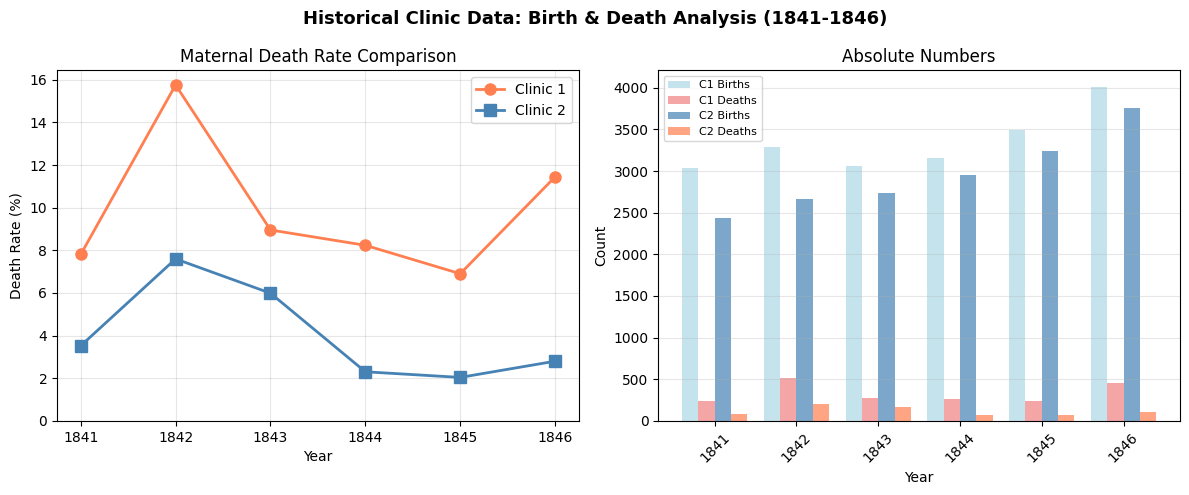

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Calculate death rates
clinic1_death_rate = [d/b*100 for d, b in zip(clinic1_deaths, clinic1_births)]
clinic2_death_rate = [d/b*100 for d, b in zip(clinic2_deaths, clinic2_births)]

# Plot death rates
axes[0].plot(years, clinic1_death_rate, 'o-', color='coral', linewidth=2, markersize=8, label='Clinic 1')
axes[0].plot(years, clinic2_death_rate, 's-', color='steelblue', linewidth=2, markersize=8, label='Clinic 2')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Death Rate (%)')
axes[0].set_title('Maternal Death Rate Comparison')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(bottom=0)

# Bar chart showing absolute numbers
x = np.arange(len(years))
width = 0.2
axes[1].bar(x - 1.5*width, clinic1_births, width, label='C1 Births', color='lightblue', alpha=0.7)
axes[1].bar(x - 0.5*width, clinic1_deaths, width, label='C1 Deaths', color='lightcoral', alpha=0.7)
axes[1].bar(x + 0.5*width, clinic2_births, width, label='C2 Births', color='steelblue', alpha=0.7)
axes[1].bar(x + 1.5*width, clinic2_deaths, width, label='C2 Deaths', color='coral', alpha=0.7)
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Count')
axes[1].set_title('Absolute Numbers')
axes[1].set_xticks(x)
axes[1].set_xticklabels(years, rotation=45)
axes[1].legend(fontsize=8)
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Historical Clinic Data: Birth & Death Analysis (1841-1846)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

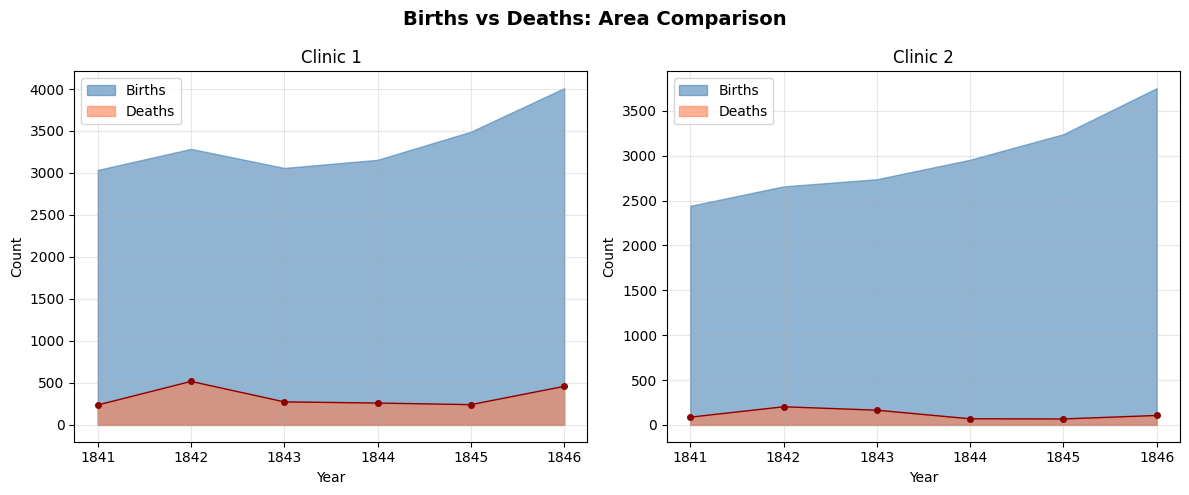

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Stacked area for clinic 1
axes[0].fill_between(years, 0, clinic1_births, alpha=0.6, color='steelblue', label='Births')
axes[0].fill_between(years, 0, clinic1_deaths, alpha=0.6, color='coral', label='Deaths')
axes[0].plot(years, clinic1_deaths, 'o-', color='darkred', linewidth=1, markersize=4)
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Count')
axes[0].set_title('Clinic 1')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Stacked area for clinic 2
axes[1].fill_between(years, 0, clinic2_births, alpha=0.6, color='steelblue', label='Births')
axes[1].fill_between(years, 0, clinic2_deaths, alpha=0.6, color='coral', label='Deaths')
axes[1].plot(years, clinic2_deaths, 'o-', color='darkred', linewidth=1, markersize=4)
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Count')
axes[1].set_title('Clinic 2')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('Births vs Deaths: Area Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

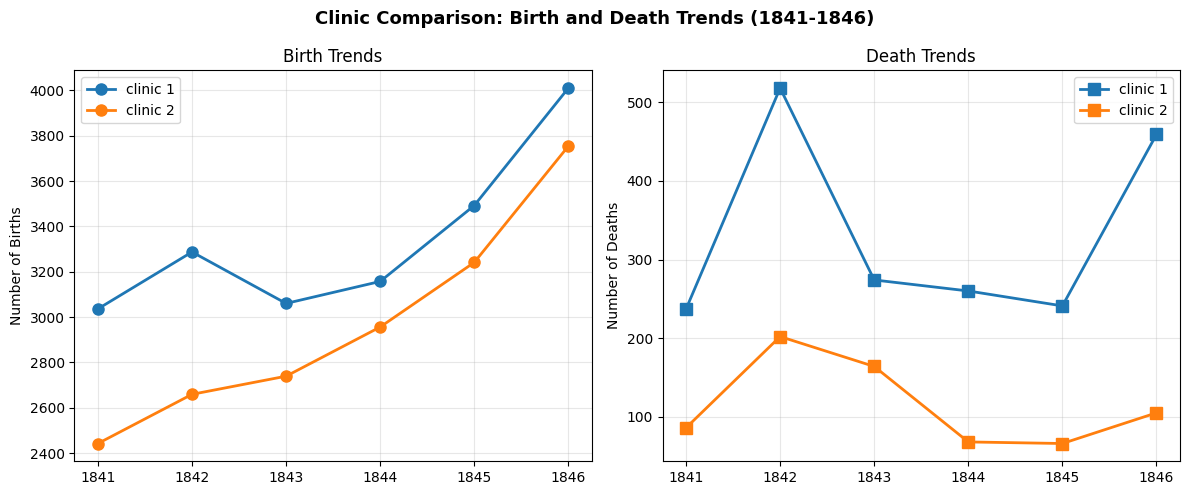

In [9]:
import pandas as pd

# Create DataFrame
df = pd.DataFrame(data)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True)

# Birth trends
for clinic in ['clinic 1', 'clinic 2']:
    clinic_data = df[df['clinic'] == clinic]
    axes[0].plot(clinic_data['year'], clinic_data['births'], 
                 'o-', linewidth=2, markersize=8, label=clinic)
axes[0].set_ylabel('Number of Births')
axes[0].set_title('Birth Trends')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(years)

# Death trends  
for clinic in ['clinic 1', 'clinic 2']:
    clinic_data = df[df['clinic'] == clinic]
    axes[1].plot(clinic_data['year'], clinic_data['deaths'], 
                 's-', linewidth=2, markersize=8, label=clinic)
axes[1].set_ylabel('Number of Deaths')
axes[1].set_title('Death Trends')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_xticks(years)

plt.suptitle('Clinic Comparison: Birth and Death Trends (1841-1846)', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()